In [1]:
import sys
!{sys.executable} -m pip install /content/GraphHDBSCAN.zip

Processing ./GraphHDBSCAN_with_uploaded_files_and_tian_example.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
import yaml
import scanpy as sc
from sklearn.neighbors import NearestNeighbors as NN
from sklearn.metrics import pairwise_distances
# Load the YAML configuration file
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Tian_config = config["DATASETS"]["Tian"]
expected_cell_label = Tian_config["cell_labels"]
# Load the AnnData object
adata = sc.read_h5ad("/content/Tian-sc_Celseq2_5cl_p1.h5ad")
# Print available columns in adata.obs
available_columns = list(adata.obs.columns)
print("Available columns in adata.obs:", available_columns)

cell_label_key = expected_cell_label

# Extract the count matrix and cell labels
count_matrix = adata.X  # Cells as rows and genes as columns
true_labels = adata.obs[cell_label_key]
print(true_labels)
# Print some basic information about the data
print("Count matrix shape:", count_matrix.shape)
print("First few cell labels:")
print(true_labels.head())


Available columns in adata.obs: ['unaligned', 'aligned_unmapped', 'mapped_to_exon', 'mapped_to_intron', 'ambiguous_mapping', 'mapped_to_ERCC', 'mapped_to_MT', 'number_of_genes', 'total_count_per_cell', 'non_ERCC_percent', 'non_mt_percent', 'non_ribo_percent', 'batch', 'outliers', 'cell_number', 'cell_line_demuxlet', 'demuxlet_cls', 'n_genes', 'norm_factor']
p1_A1       H838
p1_A10     H1975
p1_A14      A549
p1_A15     H2228
p1_A16    HCC827
           ...  
p1_P5      H1975
p1_P6       A549
p1_P7       A549
p1_P8       H838
p1_P9      H1975
Name: cell_line_demuxlet, Length: 297, dtype: category
Categories (5, object): ['A549', 'H838', 'H1975', 'H2228', 'HCC827']
Count matrix shape: (297, 1000)
First few cell labels:
p1_A1       H838
p1_A10     H1975
p1_A14      A549
p1_A15     H2228
p1_A16    HCC827
Name: cell_line_demuxlet, dtype: category
Categories (5, object): ['A549', 'H838', 'H1975', 'H2228', 'HCC827']


In [4]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,20),
    sim_graph_method="sc_gauss",
    n_neighbors=16,
    no_noise=True,
    metric="euclidean",
)


In [5]:
g.fit(adata.X)

[CORE-SG] (precomputed) CORE-SG graph has 3602 edges
[CORE-SG] m= 2: MST+tree+labels in 0.0548s
[CORE-SG] m= 3: MST+tree+labels in 0.0298s
[CORE-SG] m= 4: MST+tree+labels in 0.0158s
[CORE-SG] m= 5: MST+tree+labels in 0.0256s
[CORE-SG] m= 6: MST+tree+labels in 0.0169s
[CORE-SG] m= 7: MST+tree+labels in 0.0173s
[CORE-SG] m= 8: MST+tree+labels in 0.0248s
[CORE-SG] m= 9: MST+tree+labels in 0.0529s
[CORE-SG] m=10: MST+tree+labels in 0.0336s
[CORE-SG] m=11: MST+tree+labels in 0.0459s
[CORE-SG] m=12: MST+tree+labels in 0.0405s
[CORE-SG] m=13: MST+tree+labels in 0.0326s
[CORE-SG] m=14: MST+tree+labels in 0.0313s
[CORE-SG] m=15: MST+tree+labels in 0.0289s
[CORE-SG] m=16: MST+tree+labels in 0.0138s
[CORE-SG] m=17: MST+tree+labels in 0.0164s
[CORE-SG] m=18: MST+tree+labels in 0.0132s
[CORE-SG] m=19: MST+tree+labels in 0.0135s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], metric='euclidean', eps=1e-12, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

In [6]:
g.interactive_condensed_tree()

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5, 6…

In [7]:
labels_ = g.labels_for(18)

In [8]:
!pip install genieclust

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 49.7 MB/s eta 0:00:00


In [9]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
# Import the pair_sets_index function as PSI from genieclust.compare_partitions
from genieclust.compare_partitions import pair_sets_index as PSI

def evaluate_clustering(true_labels, predicted_labels):
    """
    Compute Normalized Mutual Information (NMI), Adjusted Rand Index (ARI),
    and Pair Set Index (PSI) between true and predicted cluster labels.

    Since PSI (pair set index) expects numeric labels, we convert the input
    labels from strings (if necessary) to integers using LabelEncoder.
    """
    # Compute NMI and ARI directly; these metrics accept string labels.
    ami = adjusted_mutual_info_score(true_labels, predicted_labels)
    ari = adjusted_rand_score(true_labels, predicted_labels)

    # Use a single LabelEncoder fitted on the union of all labels to ensure consistent encoding.
    all_labels = list(set(true_labels) | set(predicted_labels))
    encoder = LabelEncoder()
    encoder.fit(all_labels)

    # Transform true and predicted labels into numeric values.
    true_labels_numeric = encoder.transform(true_labels)
    predicted_labels_numeric = encoder.transform(predicted_labels)

    # Calculate the Pair Set Index (PSI) using the numeric labels.
    psi = PSI(true_labels_numeric, predicted_labels_numeric)

    return ami, ari, psi

# Evaluate clustering performance for option 1
# Ensure that 'true_labels' and 'labels2' (predicted labels) are defined in your environment.
ami1, ari1, psi1 = evaluate_clustering(true_labels, labels_)
print("Precomputed matrix mode:")
print("AMI:", ami1)
print("ARI:", ari1)
print("PSI:", psi1)


Precomputed matrix mode:
AMI: 0.9481596830161236
ARI: 0.9648083495818396
PSI: 0.9673381405103447


<Axes: title={'center': 'Condensed Tree for m = 18'}, ylabel='$\\lambda$ value'>

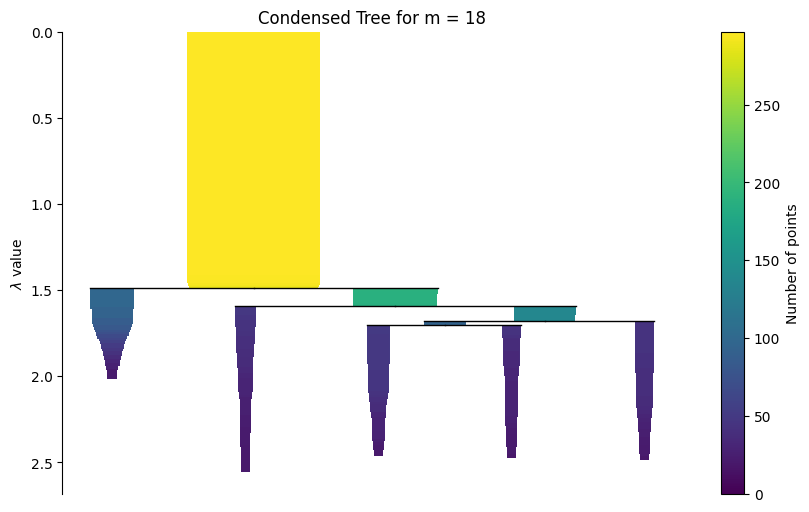

In [10]:
g.plot_condensed_tree(18)